Saving Netflix_stock_data.csv to Netflix_stock_data.csv
         Date     Close      High       Low      Open      Volume
0  2002-05-23  0.119643  0.124286  0.114571  0.115643  1047900000
1  2002-05-24  0.121000  0.122500  0.119714  0.121429   111048000
2  2002-05-28  0.115714  0.123214  0.115714  0.121357    66094000
3  2002-05-29  0.110357  0.116429  0.108571  0.116429    67578000
4  2002-05-30  0.107143  0.110786  0.107143  0.110786   101542000
Epoch 1/50


/usr/local/lib/python3.12/dist-packages/keras/src/layers/rnn/rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


187/187 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - loss: 0.0172
Epoch 2/50
187/187 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - loss: 7.5638e-05
Epoch 3/50
187/187 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - loss: 7.0366e-05
Epoch 4/50
187/187 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - loss: 6.7003e-05
Epoch 5/50
187/187 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - loss: 6.3741e-05
Epoch 6/50
187/187 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - loss: 6.3089e-05
Epoch 7/50
187/187 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - loss: 5.9555e-05
Epoch 8/50
187/187 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - loss: 6.0142e-05
Epoch 9/50
187/187 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - loss: 5.9600e-05
Epoch 10/50
187/187 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - loss: 6.0381e-05
Epoch 11/50
187/187 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - loss: 5.7853e-05
Epoch 12/50
187/187 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - loss: 5.8889e-05
Epoch 13/50
187/187 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - loss: 6.3440e-05
Epoch 14/50
187/187 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - loss: 5.9317e-05
Epoch 15/50
187/

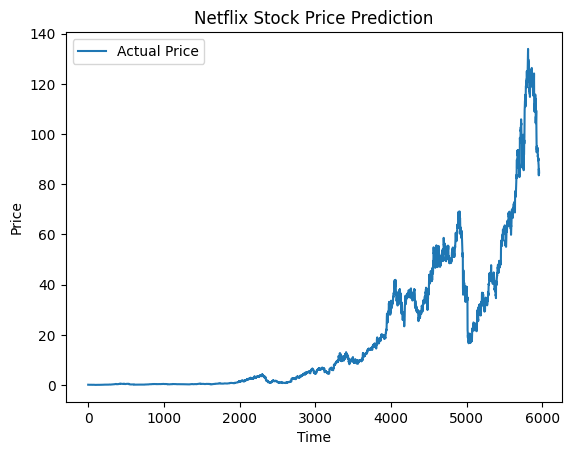

In [ ]:
# Step 1: Upload Dataset
from google.colab import files
uploaded = files.upload()

# Step 2: Import Libraries
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense
from sklearn.preprocessing import MinMaxScaler

# Step 3: Load Dataset
df = pd.read_csv("Netflix_stock_data.csv")

print(df.head())

# Step 4: Use Closing Price
data = df['Close'].values
data = data.reshape(-1, 1)

# Step 5: Normalize Data
scaler = MinMaxScaler()
data = scaler.fit_transform(data)

# Step 6: Create Dataset (3 time steps)
X = []
y = []

for i in range(len(data)-3):
    X.append(data[i:i+3])
    y.append(data[i+3])

X = np.array(X)
y = np.array(y)

# Step 7: Reshape for LSTM
X = X.reshape((X.shape[0], X.shape[1], 1))

# Step 8: Build LSTM Model
model = Sequential()

model.add(LSTM(50, activation='relu', input_shape=(3,1)))
model.add(Dense(1))

model.compile(optimizer='adam', loss='mse')

# Step 9: Train Model
model.fit(X, y, epochs=50, verbose=1)

# Step 10: Predict Next Value
test_input = data[-3:]
test_input = test_input.reshape((1, 3, 1))

prediction = model.predict(test_input)
prediction = scaler.inverse_transform(prediction)

print("Predicted next closing price:", prediction)

# Step 11: Plot Graph
plt.plot(scaler.inverse_transform(data), label="Actual Price")
plt.title("Netflix Stock Price Prediction")
plt.xlabel("Time")
plt.ylabel("Price")
plt.legend()
plt.show()